MLP autoencoder with the following layers:

Encoder and Decoder:

| Layer type    | Input size     | Output size |
|---------------|--------------|------------|
| linear + relu | # of pixels      | 100    |
| linear        | 100      | bottleneck_size    |
| linear + relu | bottleneck_size      | 100    |
| linear        | 100      | # of pixels    |


### Import relevant packages

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

### Download training data from open datasets




In [ ]:
# Download training data from open datasets.
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

# Download test data from open datasets.
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9912422/9912422 [00:00<00:00, 36561679.13it/s]


Extracting data/MNIST/raw/train-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28881/28881 [00:00<00:00, 1093608.15it/s]


Extracting data/MNIST/raw/train-labels-idx1-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1648877/1648877 [00:00<00:00, 8378714.38it/s]


Extracting data/MNIST/raw/t10k-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4542/4542 [00:00<00:00, 7143055.41it/s]

Extracting data/MNIST/raw/t10k-labels-idx1-ubyte.gz to data/MNIST/raw



### Dividing training data into train and validations sets


In [ ]:
from torch.utils.data import random_split
train_size = int(0.9 * len(training_data))  # 90% training
val_size = len(training_data) - train_size  # 10% validation

train_dataset, val_dataset = random_split(training_data, [train_size, val_size])



### Setting up the data sets for training and testing

Shape of X [N, C, H, W]: torch.Size([512, 1, 28, 28])
Shape of y: torch.Size([512]) torch.int64


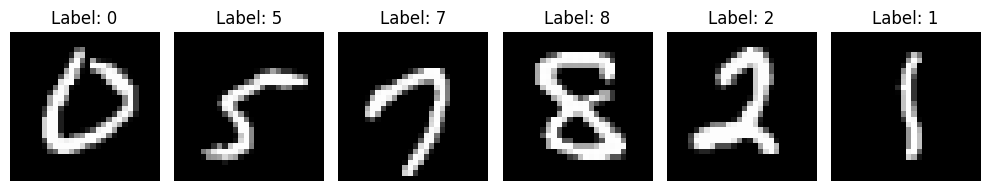

In [ ]:
batch_size = 512 # we will talk about it later

# Create data loaders.
train_dataloader = DataLoader(train_dataset, batch_size=batch_size)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in train_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")

    fig, axes = plt.subplots(1, 6, figsize=(10, 10))
    axes = axes.flatten()

    for i in range(6):
        img = X[i].squeeze().numpy()
        axes[i].imshow(img, cmap="gray")
        axes[i].set_title(f"Label: {y[i]}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

    break

### Defining the MLP autoencoder




In [ ]:
# Get cpu, gpu or mps device for training.
device = (
    "cuda" if torch.cuda.is_available()
     else "cpu"
)
print(f"Using {device} device")

# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 100),  # Linear layer with 100 neurons
            nn.ReLU(),                  # ReLU activation
            nn.Linear(100, 2)  # Linear layer with bottleneck size
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(2, 100),  # Linear layer with 100 neurons
            nn.ReLU(),                       # ReLU activation
            nn.Linear(100, 28*28)        # Linear layer to reconstruct original size
        )
    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten input since it's an MLP
        encoded = self.encoder(x)  # Get latent (encoded) representation
        decoded = self.decoder(encoded)  # Decode the latent representation
        return encoded, decoded

model = NeuralNetwork().to(device)
print(model)


Using cpu device
NeuralNetwork(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=784, bias=True)
  )
)


Sanity check for the model with a forward pass with a random input

In [ ]:
input = torch.randn(4, 28*28).to(device)  # Example random input with batch size 4

# Pass the data through the model
encoded, decoded = model(input)

# `encoded` will contain the latent representations (output from the encoder)
# `decoded` will contain the reconstructed output (output from the decoder)
print("Encoded output (latent representation):", encoded)
print("Decoded output (reconstruction):", decoded)


Encoded output (latent representation): tensor([[ 0.0355, -0.1767],
        [-0.3326,  0.1592],
        [ 0.1846,  0.2471],
        [-0.0080, -0.2044]], grad_fn=<AddmmBackward0>)
Decoded output (reconstruction): tensor([[ 1.6840e-01,  1.7144e-01,  1.6779e-01,  ..., -2.4703e-01,
         -3.0106e-01, -2.8216e-04],
        [ 2.3756e-01,  1.0731e-01,  5.6873e-02,  ..., -1.6179e-01,
         -2.8675e-01,  3.3641e-02],
        [ 2.4310e-01,  1.1683e-01,  1.9437e-01,  ..., -2.2891e-01,
         -4.2268e-01,  5.8009e-02],
        [ 1.6369e-01,  1.7104e-01,  1.5787e-01,  ..., -2.5028e-01,
         -2.8294e-01, -6.4083e-03]], grad_fn=<AddmmBackward0>)


### Defining a loss-function
Since we want the output to be as close as possible to the input, I will choose MSE as the loss function.




In [ ]:
loss_fn = nn.MSELoss(reduction = 'sum')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) # Adam optimizer

In [ ]:
train_losses = []
test_losses = []

def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    total_loss = 0  # Track the total loss for the epoch

    for batch, (X, _) in enumerate(dataloader):
        X = X.to(device)

        # Compute prediction error
        encoded, decoded = model(X)
        loss = loss_fn(decoded, X.view(X.size(0), -1))
        total_loss += loss.item()  # Accumulate loss

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
    avg_loss = total_loss / len(dataloader)  # Calculate average loss for the epoch


    train_losses.append(avg_loss)  # Store the average loss for the epoch


    print(f"Train loss: {avg_loss:>7f}\n")


In [ ]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for X, _ in dataloader:
            X = X.to(device)
            encoded, decoded = model(X)
            test_loss += loss_fn(decoded, X.view(X.size(0), -1)).item()
    test_loss /= num_batches
    test_losses.append(test_loss)  # Store the test loss for the epoch

    print(f"Test Error: \n Avg loss: {test_loss:>8f}\n")
    return test_loss

In [ ]:
epochs = 100
patience = 5
best_loss = float('inf')
early_stopping_counter = 0

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    current_val_loss = test(val_dataloader, model, loss_fn) # this is used for validation data for early stopping
    if current_val_loss < best_loss:
        best_loss = current_val_loss  # Update best loss
        early_stopping_counter = 0  # Reset counter
        print(f"Val loss improved to {best_loss:.6f}, saving model...")
        torch.save(model.state_dict(), "AE_best_model.pth")  # Save best model
    else:
        early_stopping_counter += 1
        print(f"No improvement in val loss. Early stopping counter: {early_stopping_counter}/{patience}")

    # If the patience counter reaches the patience threshold, stop training
    if early_stopping_counter >= patience:
        print("Early stopping triggered. Stopping training.")
        break

print("Done!")


Epoch 1
-------------------------------
loss: 57774.003906  [  512/54000]
loss: 22792.322266  [51712/54000]
Train loss: 27561.898207

Test Error: 
 Avg loss: 22251.981689

Val loss improved to 22251.981689, saving model...
Epoch 2
-------------------------------
loss: 22960.652344  [  512/54000]
loss: 20995.751953  [51712/54000]
Train loss: 21455.507453

Test Error: 
 Avg loss: 20383.500407

Val loss improved to 20383.500407, saving model...
Epoch 3
-------------------------------
loss: 21041.269531  [  512/54000]
loss: 20157.595703  [51712/54000]
Train loss: 20197.679033

Test Error: 
 Avg loss: 19507.028239

Val loss improved to 19507.028239, saving model...
Epoch 4
-------------------------------
loss: 20141.613281  [  512/54000]
loss: 19501.765625  [51712/54000]
Train loss: 19408.903735

Test Error: 
 Avg loss: 18879.871989

Val loss improved to 18879.871989, saving model...
Epoch 5
-------------------------------
loss: 19426.142578  [  512/54000]
loss: 19091.296875  [51712/54000]


# Check the performance of the network through train and test loss and accuracy curves

Write your code below to plot the training and test loss and accuracy for each epoch.

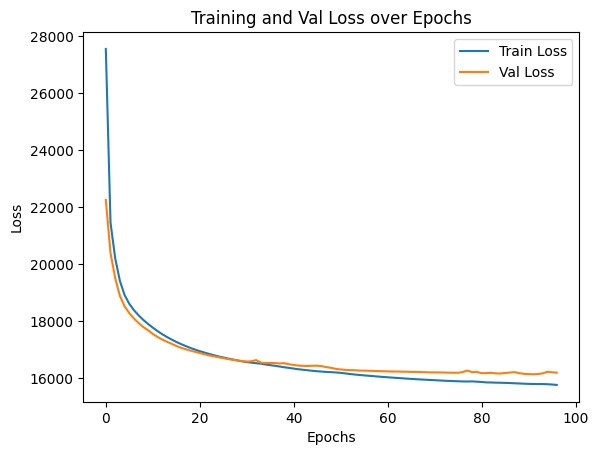

In [ ]:
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Val Loss over Epochs")
plt.legend()
plt.show()




# Check result for one image

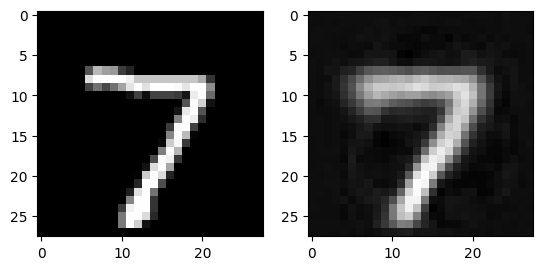

In [ ]:
model.eval()
idx = 0
x, y = test_data[idx][0], test_data[idx][1]
plt.subplot(1,2,1)
plt.imshow(x.permute(1,2,0), cmap = 'gray')
with torch.no_grad():
    x = x.to(device)
    encoded, decoded = model(x.unsqueeze(0))
    decoded_image = decoded[0,].view(28, 28)
    plt.subplot(1,2,2)
    plt.imshow(decoded_image, cmap = 'gray')




### get encodings for all test data and display it




In [ ]:
all_encodings = []
all_labels = []

model.eval()
with torch.no_grad():
    for batch in test_dataloader:
        X, y = batch
        X = X.to(device)
        encodings, _ = model(X)
        all_encodings.append(encodings.cpu())
        all_labels.append(y.cpu())

all_encodings = torch.cat(all_encodings)
all_labels = torch.cat(all_labels)

print("Shape of all encodings:", all_encodings.shape)
print("Shape of all encodings:", all_labels.shape)


Shape of all encodings: torch.Size([10000, 2])
Shape of all encodings: torch.Size([10000])


Plotting the encodings color coded with the relevant digit

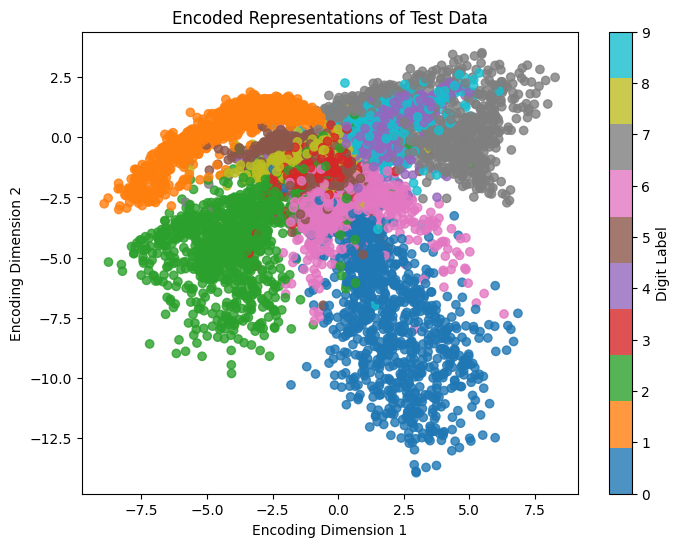

In [ ]:
encodings_np = all_encodings.numpy()
labels_np = all_labels.numpy()
plt.figure(figsize=(8, 6))
scatter = plt.scatter(encodings_np[:, 0], encodings_np[:, 1], c=labels_np, cmap='tab10', alpha=0.8, vmin = 0, vmax = 9)
plt.colorbar(scatter, label="Digit Label")
plt.title("Encoded Representations of Test Data")
plt.xlabel("Encoding Dimension 1")
plt.ylabel("Encoding Dimension 2")
plt.show()


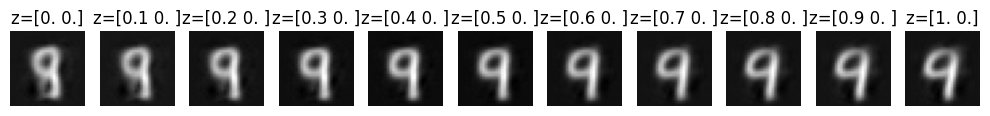

In [ ]:
encoded_values_list = [
    torch.tensor([[0.0, 0.0]], dtype=torch.float32),
    torch.tensor([[0.1, 0.0]], dtype=torch.float32),
    torch.tensor([[0.2, 0.0]], dtype=torch.float32),
    torch.tensor([[0.3, 0.0]], dtype=torch.float32),
    torch.tensor([[0.4, 0.0]], dtype=torch.float32),
    torch.tensor([[0.5, 0.0]], dtype=torch.float32),
    torch.tensor([[0.6, 0.0]], dtype=torch.float32),
    torch.tensor([[0.7, 0.0]], dtype=torch.float32),
    torch.tensor([[0.8, 0.0]], dtype=torch.float32),
    torch.tensor([[0.9, 0.0]], dtype=torch.float32),
    torch.tensor([[1.0, 0.0]], dtype=torch.float32)
]

# Make sure the model is in evaluation mode
model.eval()

fig, axes = plt.subplots(1, len(encoded_values_list), figsize=(10, 3))

for i, encoded_values in enumerate(encoded_values_list):
    with torch.no_grad():
        decoded_output = model.decoder(encoded_values)  # Decode the given encoded values
        decoded_image = decoded_output.view(28, 28).cpu()  # Reshape to image size (28x28 for MNIST)

    axes[i].imshow(decoded_image, cmap='gray')
    axes[i].set_title(f"z={encoded_values.numpy()[0]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()
